## 시퀀스 배열로 다루는 순환 신경망(RNN)

### 1.LSTM을 이용한 로이터 뉴스 카테고리 분류하기

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.datasets import reuters
from tensorflow.keras.callbacks import EarlyStopping

import numpy as np
import matplotlib.pyplot as plt

#데이터를 학습셋, 테스트셋으로 분할
(X_train, y_train), (X_test,y_test) = reuters.load_data(num_words=1000, test_split=0.2)
#num_words: 단어 사전 크기를 1000개로 제한, 자주 등장하능하는 단어 1000개만 사용
#test_split: 테스트셋의 비율을 20%로 설정
#X_train: 학습용 문장들, y_train: 학습용 정답(카테고리 번호), X_test: 테스트용 입력, y_test: 테스트용 정답

#데이터를 확인
category = np.max(y_train) + 1 #라벨은 0부터 시작하기 때문에 +1을 함 
print(category, '카테고리')
print(len(X_train), '학습용 뉴스 기사의 수')
print(len(X_test), '테스트용 뉴스 기사의 수')
print(X_train[0]) #학습데이터의 첫 번째 뉴스 기사 출력 (단어 자체가 아니라 단어를 가리키는 정수 id리스트가 출력)


46 카테고리
8982 학습용 뉴스 기사의 수
2246 테스트용 뉴스 기사의 수
[1, 2, 2, 8, 43, 10, 447, 5, 25, 207, 270, 5, 2, 111, 16, 369, 186, 90, 67, 7, 89, 5, 19, 102, 6, 19, 124, 15, 90, 67, 84, 22, 482, 26, 7, 48, 4, 49, 8, 864, 39, 209, 154, 6, 151, 6, 83, 11, 15, 22, 155, 11, 15, 7, 48, 9, 2, 2, 504, 6, 258, 6, 272, 11, 15, 22, 134, 44, 11, 15, 16, 8, 197, 2, 90, 67, 52, 29, 209, 30, 32, 132, 6, 109, 15, 17, 12]


In [ ]:
#단어의 수를 맞추어 줍니다.
#입력 길이가 일정해야 배치로 묶어서 학습할 수 있음
#각 샘플을 길이 100으로 맞춰 짧으면 모자란 부분은 0으로 채우고(padding) 길면 잘라냄
X_train = sequence.pad_sequences(X_train, maxlen=100)
X_test = sequence.pad_sequences(X_test, maxlen=100)
#학습 입력과 테스트 입력 형태는 동일해야함


#원 -핫 인코딩 처리를 합니다. : 숫자 라벨인 정답을 46칸 짜리 원-핫 벡터로 바꿈 
y_train = to_categorical(y_train)
y_test = to_categorical(y_test) 


#모델의 구조를 설정합니다.
model = Sequential()
model.add(Embedding(1000, 100))
#input_dim = 1000, output_dim =100차원 벡터로 표현, 단어 id(0~999)를 100차원 벡터로 변환
model.add(LSTM(100, activation ='tanh')) #단어 순서를 따라 읽으면서 기사 내용을 요약해 100차원으로 만듦
model.add(Dense(46, activation='softmax')) #46개 카테고리 각각을 확률로 출력

#학습 실행 옵션 
model.compile(loss='categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

#학습의 조기 중단 설정 (과적합 방지)
early_stopping_callback = EarlyStopping(monitor ='val_loss', patience = 5)

#모델 학습
history = model.fit(X_train, y_train, batch_size = 20, epochs =200, validation_data =(X_test, y_test), callbacks = [early_stopping_callback])

#테스트 정확도 출력
print('\n Test Accuracy: %.4f' % (model.evaluate(X_test, y_test)[1]))
#반환값 [loss, accuracy] 중에서 두 번째 값인 accuracy만 꺼냄 (compile에서 metrics로 accuracy로 지정했기 때문에)
#정확도 숫자를 소수점 4자리까지 포맷팅
#줄바꿈 후 출력

Epoch 1/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.4725 - loss: 2.1175 - val_accuracy: 0.5227 - val_loss: 2.0651
Epoch 2/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.5513 - loss: 1.7360 - val_accuracy: 0.5828 - val_loss: 1.6698
Epoch 3/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.6303 - loss: 1.4843 - val_accuracy: 0.6443 - val_loss: 1.4336
Epoch 4/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.6752 - loss: 1.2972 - val_accuracy: 0.6603 - val_loss: 1.3477
Epoch 5/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.7030 - loss: 1.1738 - val_accuracy: 0.6710 - val_loss: 1.2858
Epoch 6/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.7221 - loss: 1.0824 - val_accuracy: 0.6901 - val_loss: 1.2239
Epoch 7/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.7519 - loss: 0.9763 - val_accuracy: 0.7030 - val_loss: 1.1668
Epoch 8/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.7710 - loss: 0.8861 -

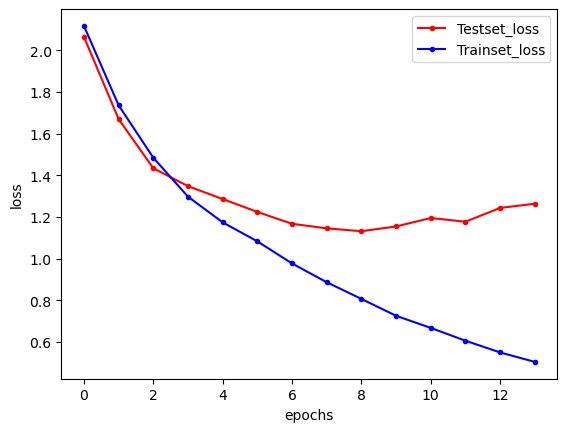

In [50]:
#학습셋과 테스트셋의 오차 저장
y_vloss = history.history['val_loss']
y_loss = history.history['loss']

x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker='.', c='red', label='Testset_loss')
plt.plot(x_len, y_loss, marker='.', c='blue', label='Trainset_loss')
plt.legend()
plt.xlabel('epochs')
plt.ylabel('loss')
plt.show()

## 2.LSTM과 CNN의 조합을 이용한 영화 리뷰 분류하기

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Embedding, LSTM, Conv1D, MaxPooling1D
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.callbacks import EarlyStopping

import numpy as np
import matplotlib.pyplot as plt

#1) 데이터 불러오기
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=5000) #자주 나오는 단어 5000개만 사용
#2) 문장 길이 통일(padding)
X_train = sequence.pad_sequences(X_train, maxlen=500) #리뷰 (단어 id 리스트들) 문장 길이 500으로 통일
X_test = sequence.pad_sequences(X_test, maxlen=500) #정답(긍정=1, 부정=0) 문장길이 500으로 통일
#3) 모델 만들기
model = Sequential()
#3)-1 : Embedding 단어 id -> 의미 벡터
model.add(Embedding(5000,100)) #단어 id(0~4999)를 100차원 벡터로 바꿔서 의미를 부여함
#과적합 방지
model.add(Dropout(0.5))
#3)-2 : Conv1D (1차원 합성곱: 짧은 문구 패턴 잡기)
# 64개 필터(패턴 탐지기)로 연속된 단어 5개씩 패턴을 훑어봄, 음수는 0으로 중요한 신호를 살리고 가장자리 패딩 없이 길이가 조금 줄어듦
model.add(Conv1D(64, 5, padding='valid', activation='relu', strides=1))
#3)-3 : MaxPooling1D (중요한 패턴만 압축): 4칸씩 묶어 가장 큰 값만 남김, 길이를 줄여서 계산량을 줄임 
model.add(MaxPooling1D(pool_size=4))
#3)-4 : LSTM (전체 흐름 순서 요약, 문장 전체 의미를 요약, 최종적으로 50차원 정도의 요약 벡터를 만듦)
model.add(LSTM(50))
#3)-6 : 출력 1개, 긍정일 확률
model.add(Dense(1))
#3)-7 : 활성화 함수, 확률로 변환
model.add(Activation('sigmoid'))
#(배치 크기, 각 샘플의 길이)
model.build(input_shape=(None,100))
#각 레이어가 어떤 shape로 연결되는지 한 눈에 보여줌
model.summary()


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ (None, 100, 100)       │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 100)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 96, 64)         │        32,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 50)             │        23,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            51 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 555,115 (2.12 MB)

 Trainable params: 555,115 (2.12 MB)

 Non-trainable params: 0 (0.00 B)

In [52]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

early_stopping_callback = EarlyStopping(monitor='val_loss', patience=3)

history=model.fit(X_train, y_train, batch_size=40, epochs=100, validation_split=0.25, callbacks=[early_stopping_callback])

print('\n Test Accuracy: %.4f' %(model.evaluate(X_test, y_test)[1]))

Epoch 1/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.7880 - loss: 0.4232 - val_accuracy: 0.8696 - val_loss: 0.3111
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.9071 - loss: 0.2399 - val_accuracy: 0.8930 - val_loss: 0.2597
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.9296 - loss: 0.1859 - val_accuracy: 0.8933 - val_loss: 0.2709
Epoch 4/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.9451 - loss: 0.1513 - val_accuracy: 0.8896 - val_loss: 0.2789
Epoch 5/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - accuracy: 0.9560 - loss: 0.1214 - val_accuracy: 0.8862 - val_loss: 0.3069
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8784 - loss: 0.3249

 Test Accuracy: 0.8784


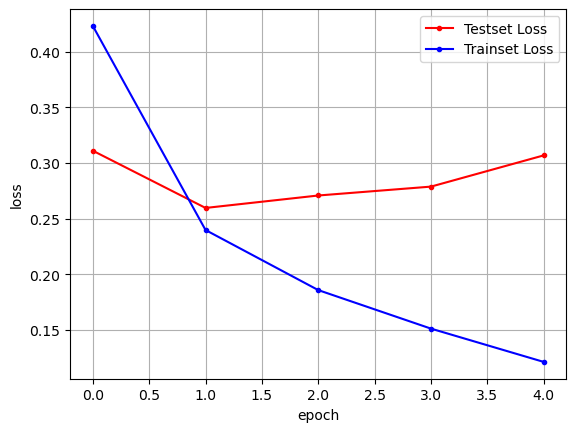

In [53]:
#학습셋과 테스트셋의 오차 저장
y_vloss = history.history['val_loss']
y_loss = history.history['loss']

#그래프로 표현
x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker='.', c='red', label='Testset Loss')
plt.plot(x_len, y_loss, marker='.', c='blue', label='Trainset Loss')

#그래프에 그리드 주고 레이블 표시 
plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

## 3. 어텐션을 사용한 신경망

In [54]:
pip install keras-self-attention

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [55]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Embedding, LSTM, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model
from keras_self_attention import SeqSelfAttention


In [56]:
import numpy as np
import matplotlib.pyplot as plt

In [57]:
#데이터를 불러와 학습셋, 테스트셋으로 나누기
#IMDB 데이터셋에서 자주 사용되는 단어 상위 5000개만 가져오기 
(X_train, y_train),(X_test, y_test) = imdb.load_data(num_words=5000)

#단어의 수를 맞추기 (Padding) 
#모델이 읽을 수 있게 500단어로 길이를 통일, 500자보다 짧으면 0으로 채우고, 길면 뒤부분 자르기
X_train = sequence.pad_sequences(X_train, maxlen=500)
X_test = sequence.pad_sequences(X_test, maxlen=500)

#모델의 구조 설정
model = Sequential()
model.add(Embedding(5000,500)) #숫자(인덱스)로 된 단어를 500차원의 공간에 배치
model.add(Dropout(0.5)) #학습 시 데이터의 50%를 무작위로 무시해 과적합 방지
model.add(LSTM(64, return_sequences=True))#문맥 파악: 문장의 앞 뒤 흐름을 기억하는 층
#return_sequences=True: 다음 층으로 전달할 때도 시퀀스를 유지
model.add(SeqSelfAttention(attention_activation='sigmoid') #집중할 단어 선택: 문장에서 어떤 단어가 감정 분석에 중요한지 가중치 계산 
model.add(Dropout(0.5))
model.add(Flatten())#2차원 데이터를 1차원 긴 줄로 펼쳐서 마지막 판단 층(Dense)로 전달
model.add(Dense(1))
model.add(Activation('sigmoid'))#최종 판단: 모든 정보를 종합해 0(부정) 또는 1(긍정)으로 판단

#모델의 실행 옵션 정하기
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

#학습의 조기 중단 설정 : val_loss가 3번 연속으로 개선되지 않으면 학습 중단
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=3)

#모델 학습: 전체 데이터를 최대 100번 반복해서 학습시키며, 40개씩 묶어서 학습
history = model.fit(X_train, y_train, epochs=100, batch_size=40, validation_data=(X_test, y_test), callbacks=[early_stopping_callback])

#테스트 정확도 출력 
print('\n Test Accuracy: %.4f'% (model.evaluate(X_test,y_test)[1]))

SyntaxError: '(' was never closed (3466213871.py, line 16)

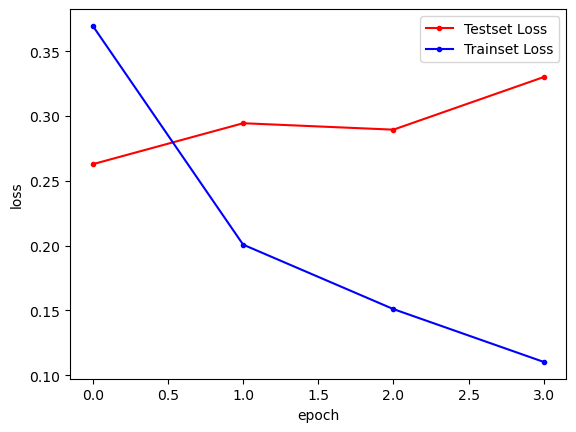

In [ ]:
#학습셋과 테스트셋의 오차 저장해서 학습을 잘 했는지 과적합했는지 판단하는 과정
y_vloss = history.history['val_loss'] #검증 데이터의 오차
y_loss = history.history['loss'] #학습 데이터의 오차


x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker='.', c='red', label='Testset Loss')
plt.plot(x_len, y_loss, marker='.', c='blue', label='Trainset Loss')

plt.legend()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()